<a href="https://colab.research.google.com/github/wesleyc00/data-science/blob/main/ESTATISTICA_II_E_REGRESS%C3%83O_LINEAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ESTATISTICA II E REGRESSÃO LINEAR

## T DE STUDENT

In [ ]:
from scipy.stats import t

### Média do salário de cientistas de dados = R$75.00 a hora
### Amostra com 9 funcionários e desvio padrão = 10.

In [ ]:
# Qual a probabilidade de selecionar um cientista de dados que recebe menos que R$ 80 por hora?
p_direita = t.cdf(1.5, 8)
p_direita

np.float64(0.9139983540240443)

In [ ]:
# Qual a probabilidade do salário ser maior que R$80?
p_esquerda = t.sf(1.5, 8)
p_esquerda

np.float64(0.08600164597595565)

In [ ]:
# Somatório das probabilidades
somatorio_prob = p_direita + p_esquerda
print(somatorio_prob)

0.9999999999999999


## Distribuição de Poisson

In [ ]:
from scipy.stats import poisson

### Média de acidente de carros é de 2 por dia

In [ ]:
# Qual a probabilidade de ocorrer 3 acidentes no dia?
poisson.pmf(3, 2)

np.float64(0.18044704431548356)

In [ ]:
# Qual a probabilidade de ocorrer 3 ou menos acidentes no dia?
poisson.cdf(3, 2)

np.float64(0.857123460498547)

In [ ]:
# Qual a probabilidade de ocorrer mais de 3 acidentes no dia?
poisson.sf(0, 2)

np.float64(0.8646647167633873)

## Distribuição binomial

In [ ]:
from scipy.stats import binom

In [ ]:
# Se jogar uma moeda 5 vezes, qual a probabilidade de dar cara 3 vezes?
# eventos, experimentos, probabilidade.
# 3, 5, 1/2.

prob = binom.pmf(3, 5, 0.5)
#exibir apenas 2 casas decimais após a virgula|
print(f'A probabilidade é de {prob*100:.2f}%')

A probabilidade é de 31.25%


In [ ]:
# qual a probabilidade de passar por 4 sinais de 4 tempos e pegar sinal verde?
# nenhuma, 1, 2, 3, 4 vezes em seguida?
binom.pmf(0,4,0.25) + binom.pmf(1,4,0.25) + binom.pmf(2,4,0.25) + binom.pmf(3,4,0.25) + binom.pmf(4,4,0.25)

np.float64(1.0000000000000002)

In [ ]:
# E se forem sinais de dois tempos?
binom.pmf(4, 4, 0.5)

np.float64(0.0625)

In [ ]:
# Probabilidade cumulativa
binom.cdf(4, 4, 0.25)

np.float64(1.0)

In [ ]:
# Concurso com 12 questões, qual a probabilidade de acertar 7 questões
# considerando que cada questão tem 4 alternativas?
binom.pmf(7, 12, 0.25) * 100

np.float64(1.1471271514892587)

In [ ]:
# Probabilidade de acertar as 12 questões
binom.pmf(12, 12, 0.25)

np.float64(5.960464477539063e-08)

### Qui Quadrado

In [ ]:
# Importação das funões
import numpy as np
from scipy.stats import chi2_contingency

In [ ]:
# Criar matriz com dados e execução do teste
novela = np.array([[19, 6], [43, 32]])
novela

array([[19,  6],
       [43, 32]])

In [ ]:
# Segundo valor é o pvalue
# valor de p é maior que 0,05 não há evidências de diferença significativa(hipotese nula)

chi2_contingency(novela)

Chi2ContingencyResult(statistic=np.float64(2.037351443123939), pvalue=np.float64(0.15347667161786666), dof=1, expected_freq=array([[15.5,  9.5],
       [46.5, 28.5]]))

In [ ]:
novela2 = np.array([[22, 3], [43, 32]])
novela2

array([[22,  3],
       [43, 32]])

In [ ]:
# agora o valor de p é menor que 0,05 podemos rejeitar a hipotese nula.
chi2_contingency(novela2)

Chi2ContingencyResult(statistic=np.float64(6.461538461538461), pvalue=np.float64(0.011023416388221425), dof=1, expected_freq=array([[16.25,  8.75],
       [48.75, 26.25]]))

### ANOVA

In [ ]:
# Importação de bibliotecas
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

In [ ]:
# Carregamento da base de dados
tratamento = pd.read_csv('/content/anova.csv', sep = ';')
tratamento.head()

,Sexo,Remedio,Horas
0,F,A,5
1,F,A,10
2,F,A,7
3,F,A,7
4,M,A,7


<Axes: title={'center': 'Horas'}, xlabel='[Remedio]'>

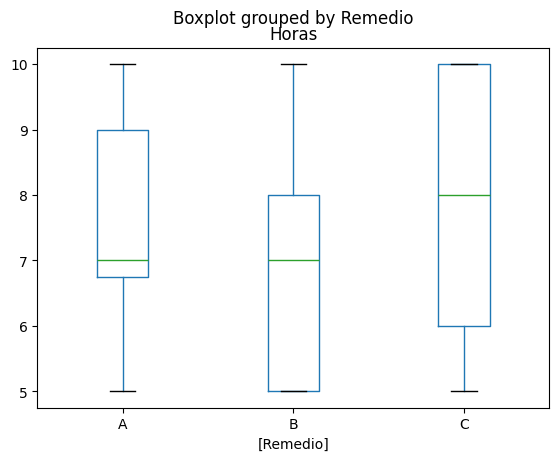

In [ ]:
# Boxplot agrupando os dados pelo remédio
tratamento.boxplot(by = 'Remedio', grid = False)

In [ ]:
# Criação do modelo de regressão linear e execução do teste
modelo1 = ols('Horas ~ Remedio', data = tratamento).fit()
resultados1 = sm.stats.anova_lm(modelo1)
# Observar valor de p maior que 0,05 (Pr(>F)) Hipotese nula de que não há diferença significativa.
resultados1

,df,sum_sq,mean_sq,F,PR(>F)
Remedio,2.0,4.083333,2.041667,0.537618,0.591966
Residual,21.0,79.750000,3.797619,NaN,NaN


In [ ]:
# Criação do segundo modelo utilizando mais atributos e execução do teste
modelo2 = ols('Horas ~ Remedio * Sexo', data = tratamento).fit()
resultados2 = sm.stats.anova_lm(modelo2)
# Observar valor de p menor que 0,05 (Pr(>F)) Hipotese n
resultados2

,df,sum_sq,mean_sq,F,PR(>F)
Remedio,2.0,4.083333,2.041667,0.532609,0.596042
Sexo,1.0,4.166667,4.166667,1.086957,0.310948
Remedio:Sexo,2.0,6.583333,3.291667,0.858696,0.440360
Residual,18.0,69.000000,3.833333,NaN,NaN


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper reject
-------------------------------------------------
     A      B   -0.625 0.7991 -3.081 1.831  False
     A      C    0.375 0.9219 -2.081 2.831  False
     B      C      1.0 0.5689 -1.456 3.456  False
-------------------------------------------------


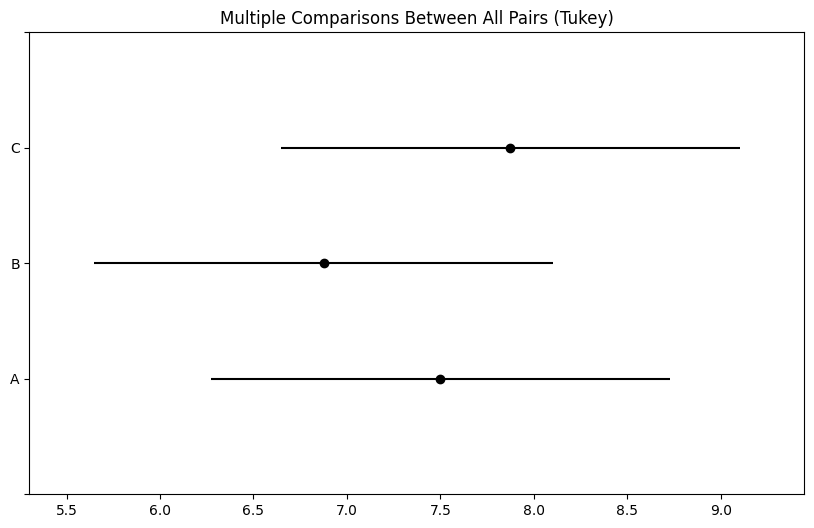

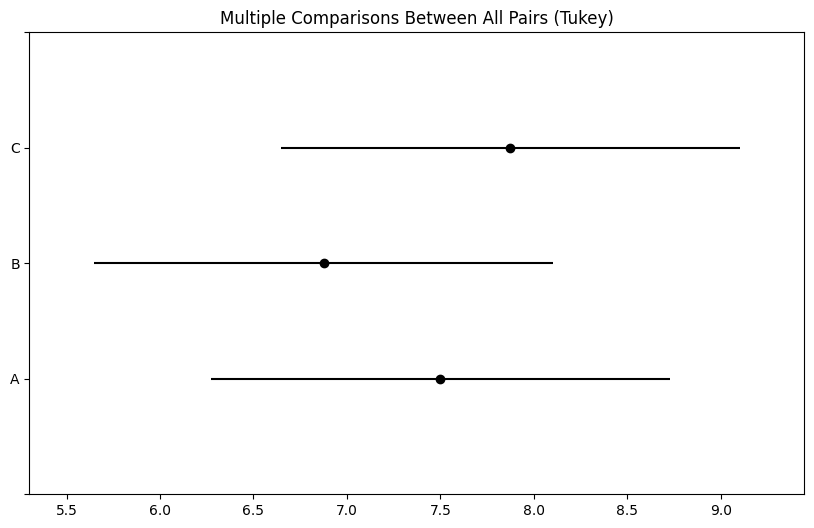

In [ ]:
# Se houver diferença o teste de Yukey é executado
# Execução do teste de Tukey e visualização dos gráficos com resultados
mc = MultiComparison(tratamento['Horas'], tratamento['Remedio'])
resultado_teste = mc.tukeyhsd()
print(resultado_teste)
resultado_teste.plot_simultaneous()

## REGRESSÃO LINEAR

In [ ]:
# Importando bibliotecas, sklearn para criar o modelo de regressão e yellowbrick para visualização de residuai
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib as plt
import matplotlib.pyplot as plt
# Warning
from yellowbrick.regressor import ResidualsPlot

In [ ]:
base = pd.read_csv('/content/cars.csv')
base.shape

(50, 3)

In [ ]:
base.head()

,Unnamed: 0,speed,dist
0,1,4,2
1,2,4,10
2,3,7,4
3,4,7,22
4,5,8,16


In [ ]:
base = base.drop(['Unnamed: 0'], axis = 1)
base.head()

,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


In [ ]:
# Definição das variáveis X e Y, X distância é a variável independente e Y velocidade é a variável dependente

X = base.iloc[:, 1].values
y = base.iloc[:, 0].values
X

array([  2,  10,   4,  22,  16,  10,  18,  26,  34,  17,  28,  14,  20,
        24,  28,  26,  34,  34,  46,  26,  36,  60,  80,  20,  26,  54,
        32,  40,  32,  40,  50,  42,  56,  76,  84,  36,  46,  68,  32,
        48,  52,  56,  64,  66,  54,  70,  92,  93, 120,  85])

In [ ]:
# Calculo da correlação entre X e Y
correlacao = np.corrcoef(X, y)
correlacao

array([[1.       , 0.8068949],
       [0.8068949, 1.       ]])

In [ ]:
# Formato de matriz com uma coluna a mais
X = X.reshape(-1, 1)
# Criação do modelo e treinamento (fit indica que o treinamento deve ser executado)
modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [ ]:
# Visualização dos coeficientes
modelo.intercept_

np.float64(8.283905641787172)

In [ ]:
# Inclinação
modelo.coef_

array([0.16556757])

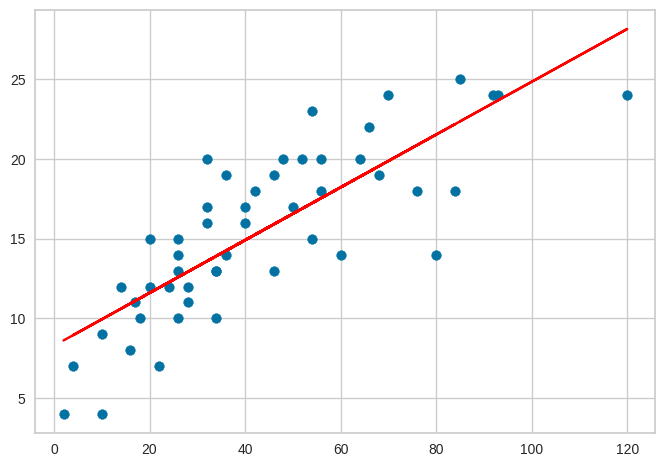

In [ ]:
# Geração do gráfico com os pontos reais e as previsões
plt.scatter(X, y)
plt.plot(X, modelo.predict(X), color = 'red')

In [ ]:
# Previsão da distância 22 pés usando a formula manual
# Interceptação * inclinação * valor de dist
modelo.intercept_ + modelo.coef_ * 22

array([11.92639228])

In [ ]:
# Previsão utilizando a função do sklearn
modelo.predict([[22]])

array([11.92639228])

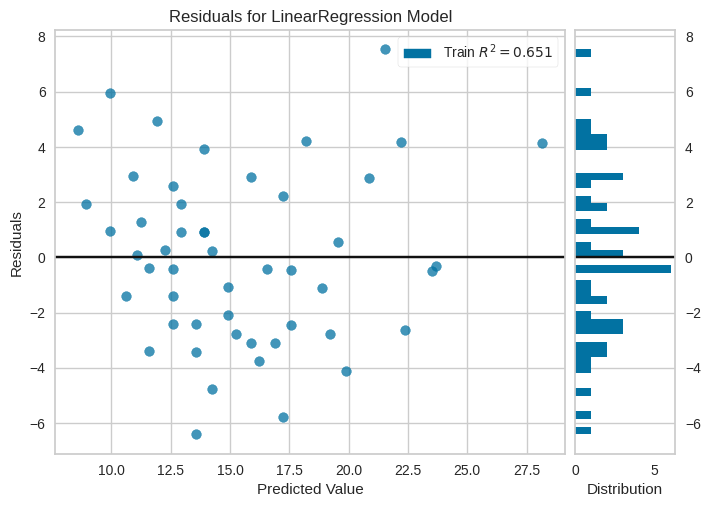

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [ ]:
# Gráfico para visualizar os residuais
visualizador = ResidualsPlot(modelo)
visualizador.fit(X, y)
visualizador.poof()

## Regressão Linear Multipla

In [1]:
# Importação de libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as sm

In [4]:
# Carregamento da base de dados e exclusão da primeira coluna
base = pd.read_csv('/content/mt_cars.csv')
base.shape

(32, 12)

In [5]:
#mpeg consumo, cyl cilindros, disp cilindros, hp
base.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [6]:
# exclui coluna
base = base.drop(['Unnamed: 0'], axis = 1)
base.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [7]:
# Criação de X e Y: variável independente e variável dependente
# Cálculo da correlação entre X e Y
X = base.iloc[:, 2].values # Coluna disp
y = base.iloc[:, 0].values # Coluna mpg
correlacao = np.corrcoef(X, y)
correlacao

array([[ 1.        , -0.84755138],
       [-0.84755138,  1.        ]])

In [8]:
# Mudança do formato de X para o formato de matriz (necessário para versões mais recentes do sklearn)
X = X.reshape(-1, 1)

In [9]:
# Criação do modelo, treinamento, visualização dos coeficientes e do score do modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Interceptação
modelo.intercept_

np.float64(29.599854756163946)

In [10]:
# Inclinação
modelo.coef_

array([-0.04121512])

In [11]:
# Score R^2
modelo.score(X,y)

0.7183433404897299

In [12]:
# Geração das previsões
previsoes = modelo.predict(X)
previsoes

array([23.00543556, 23.00543556, 25.1486218 , 18.96635381, 14.76241157,
       20.32645276, 14.76241157, 23.55359666, 23.79676587, 22.69220065,
       22.69220065, 18.23272467, 18.23272467, 18.23272467, 10.14631813,
       10.64089957, 11.46520197, 26.35622482, 26.47987017, 26.66945973,
       24.64991885, 16.49344661, 17.07045829, 15.17456277, 13.11380677,
       26.34386028, 24.64167582, 25.68029685, 15.13334765, 23.62366236,
       17.19410365, 24.61282524])

In [13]:
# Criação do modelo, utilizando a biblioteca stats model
modelo_ajustado = sm.ols(formula = 'mpg ~ disp', data = base)
modelo_treinado = modelo_ajustado.fit()
modelo_treinado.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     76.51
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           9.38e-10
Time:                        19:36:01   Log-Likelihood:                -82.105
No. Observations:                  32   AIC:                             168.2
Df Residuals:                      30   BIC:                             171.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.5999      1.230     24.070      0.000      27.088      32.111
disp          -0.0412      0.005     -8.747      0.000      -0.051      -0.032
==============================================================================
Omnibus:                        3.368   Durbin-Watson:                   1.250
Prob(Omnibus):                  0.186   Jarque-Bera (JB):                3.049
Skew:                           0.719   Prob(JB):                        0.218
Kurtosis:                       2.532   Cond. No.                         558.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

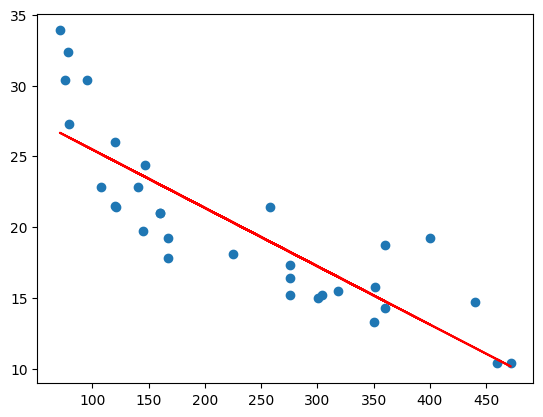

In [14]:
# Visualização dos resultados
plt.scatter(X, y)
plt.plot(X, previsoes, color = 'red')

In [15]:
# Previsão para somente um valor
modelo.predict([[200]])

array([21.35683076])

In [16]:
# Criação de novas variáveis X1 e Y1 e novo modelo para comparação com o anterior
# 3 Variáveis dependentes para prever mpg: cyl -> disp -> hp
X1 = base.iloc[:, 1:4].values
X1

array([[  6. , 160. , 110. ],
       [  6. , 160. , 110. ],
       [  4. , 108. ,  93. ],
       [  6. , 258. , 110. ],
       [  8. , 360. , 175. ],
       [  6. , 225. , 105. ],
       [  8. , 360. , 245. ],
       [  4. , 146.7,  62. ],
       [  4. , 140.8,  95. ],
       [  6. , 167.6, 123. ],
       [  6. , 167.6, 123. ],
       [  8. , 275.8, 180. ],
       [  8. , 275.8, 180. ],
       [  8. , 275.8, 180. ],
       [  8. , 472. , 205. ],
       [  8. , 460. , 215. ],
       [  8. , 440. , 230. ],
       [  4. ,  78.7,  66. ],
       [  4. ,  75.7,  52. ],
       [  4. ,  71.1,  65. ],
       [  4. , 120.1,  97. ],
       [  8. , 318. , 150. ],
       [  8. , 304. , 150. ],
       [  8. , 350. , 245. ],
       [  8. , 400. , 175. ],
       [  4. ,  79. ,  66. ],
       [  4. , 120.3,  91. ],
       [  4. ,  95.1, 113. ],
       [  8. , 351. , 264. ],
       [  6. , 145. , 175. ],
       [  8. , 301. , 335. ],
       [  4. , 121. , 109. ]])

In [18]:
y1 = base.iloc[:, 0].values
modelo2 = LinearRegression()
modelo2.fit(X1, y1)
# R^2
modelo2.score(X1, y1)

0.7678877440928638

In [19]:
# Criação do modelo ajustado com mais atributos (regressão linear multipla)
modelo_ajustado2 = sm.ols(formula = 'mpg ~ cyl + disp + hp', data = base)
modelo_treinado2 = modelo_ajustado2.fit()
modelo_treinado2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     30.88
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           5.05e-09
Time:                        19:39:30   Log-Likelihood:                -79.009
No. Observations:                  32   AIC:                             166.0
Df Residuals:                      28   BIC:                             171.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.1849      2.591     13.195      0.000      28.878      39.492
cyl           -1.2274      0.797     -1.540      0.135      -2.861       0.406
disp          -0.0188      0.010     -1.811      0.081      -0.040       0.002
hp            -0.0147      0.015     -1.002      0.325      -0.045       0.015
==============================================================================
Omnibus:                        2.942   Durbin-Watson:                   1.606
Prob(Omnibus):                  0.230   Jarque-Bera (JB):                2.558
Skew:                           0.675   Prob(JB):                        0.278
Kurtosis:                       2.692   Cond. No.                     1.51e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
# Previsão de um novo registro
novo = np.array([4, 200, 100])
novo = novo.reshape(1, -1)
modelo2.predict(novo)

array([24.03968887])

## * Faça você mesmo, exercicio de regressão lienar em python:
### 1 Franquias
  1. FraAnual: Taxa Anual
  2. CusInic: Investimento Inicial
#### 2. Criar um modelo de regressão linear para prever qual será o investimento inicial necessário de uma franquia a partir da Taxa Anual cobrado pelo franqueador

In [21]:
# Carregar bibliotecas que serão utilizadas no modelo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
from sklearn.linear_model import LinearRegression

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
from sklearn.linear_model import LinearRegression

# Carregar dataset slr12.csv
base = pd.read_csv('/content/slr12.csv', sep = ';')
base.head()

,FrqAnual,CusInic
0,1000,1050
1,1125,1150
2,1087,1213
3,1070,1275
4,1100,1300


In [33]:
# A partir da Taxa Anual (variável independente = X) preciso prever o investimento inicial (Y - Dependente)
# Separar colunas por ';' usando o sep = ';'
X = base.iloc[:, 0].values
y = base.iloc[:, 1].values

# Correlação
correlacao = np.corrcoef(X, y)
correlacao

array([[1.        , 0.47700725],
       [0.47700725, 1.        ]])

In [34]:
# Mudança do formato de X para o formato de matriz (necessário para versões mais recentes do sklearn)
X = X.reshape(-1, 1)

In [35]:
# Treinar modelo de regressão linear
modelo = LinearRegression()
modelo.fit(X, y)

# Interceptação
modelo.intercept_

np.float64(867.6042222620559)

In [36]:
# Inclinação
modelo.coef_

array([0.37315794])

In [37]:
# Calcular score R^2
modelo.score(X,y)

0.2275359181555099

In [39]:
# Geração das previsões
previsoes = modelo.predict(X)
previsoes

array([1240.76215819, 1287.40690018, 1273.22689862, 1266.88321371,
       1278.07795178, 1296.73584858, 1334.05164217, 1296.73584858,
       1278.07795178, 1371.36743577, 1343.38059057, 1380.69638416,
       1306.06479698, 1315.39374538, 1306.06479698, 1352.70953897,
       1337.78322153, 1363.90427705, 1362.03848737, 1315.39374538,
       1324.72269377, 1274.34637242, 1268.74900339, 1270.61479307,
       1270.61479307, 1307.93058666, 1324.72269377, 1306.06479698,
       1334.05164217, 1334.05164217, 1147.47267421, 1287.40690018,
       1128.81477741, 1203.4463646 , 1203.4463646 , 1184.7884678 ])

In [41]:
# Criação do modelo, utilizando a biblioteca stats model
modelo_ajustado = sm.ols(formula = 'FrqAnual ~ CusInic', data = base)
modelo_treinado = modelo_ajustado.fit()
modelo_treinado.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               FrqAnual   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                     10.01
Date:                Thu, 24 Sep 2026   Prob (F-statistic):            0.00327
Time:                        20:25:19   Log-Likelihood:                -228.31
No. Observations:                  36   AIC:                             460.6
Df Residuals:                      34   BIC:                             463.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    347.5467    249.872      1.391      0.173    -160.254     855.348
CusInic        0.6098      0.193      3.165      0.003       0.218       1.001
==============================================================================
Omnibus:                       18.151   Durbin-Watson:                   1.224
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.634
Skew:                          -1.601   Prob(JB):                     2.01e-05
Kurtosis:                       5.043   Cond. No.                     1.37e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.37e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

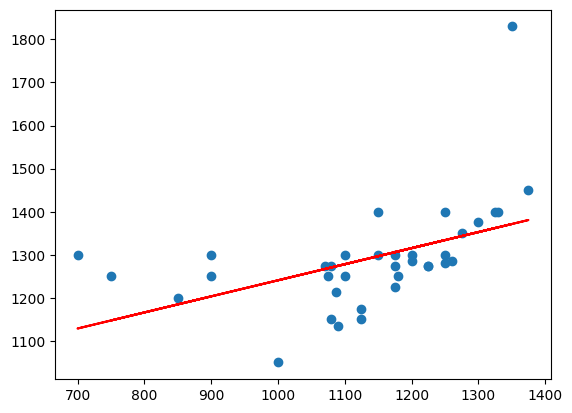

In [42]:
# Gerando gráfico de previsões
plt.scatter(X, y)
plt.plot(X, previsoes, color = 'red')

In [44]:
# Testando com um novo valor
novo = np.array([1000])
novo = novo.reshape(-1, 1)
modelo.predict(novo)

array([1240.76215819])